# Sales Forecasting & Demand Prediction Project

## Objective
To predict future sales using historical retail sales data and create a business intelligence dashboard using Power BI.

## Tools Used
- Google Colab
- Python
- Pandas
- Matplotlib
- Seaborn
- Prophet
- Power BI

# Installing Required Libraries

In [7]:
!pip install prophet pmdarima plotly seaborn statsmodels -q

# Uploading Dataset

In [8]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


# Importing Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset

In [10]:
df = pd.read_csv("train.csv")

/tmp/ipykernel_1781/2292805398.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


# Understanding the Dataset

In [11]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [12]:
df.shape

(1017209, 9)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [14]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


# Data Cleaning & Preprocessing

In [15]:
df['Date'] = pd.to_datetime(df['Date'])

In [16]:
df = df.sort_values('Date')

In [17]:
df.fillna(0, inplace=True)

# Feature Engineering

In [18]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['IsWeekend'] = df['DayOfWeek'].isin([5,6]).astype(int)

# Aggregating Daily Sales

In [19]:
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()

# Weekly Sales Aggregation

In [20]:
weekly_sales = daily_sales.set_index('Date').resample('W').sum().reset_index()

In [21]:
weekly_sales.head()

,Date,Sales
0,2013-01-06,26129335
1,2013-01-13,49275222
2,2013-01-20,34377765
3,2013-01-27,46040169
4,2013-02-03,38466029


# Exporting Cleaned Dataset

In [22]:
weekly_sales.to_csv("weekly_sales.csv", index=False)

# Exploratory Data Analysis (EDA)

## Weekly Sales Trend

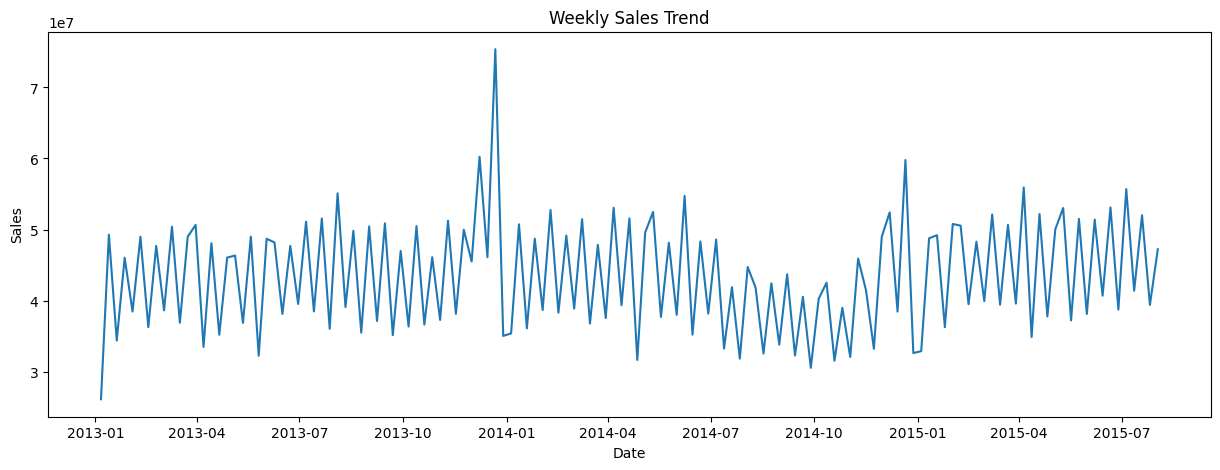

In [23]:
plt.figure(figsize=(15,5))

plt.plot(
    weekly_sales['Date'],
    weekly_sales['Sales']
)

plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

## Monthly Sales Analysis

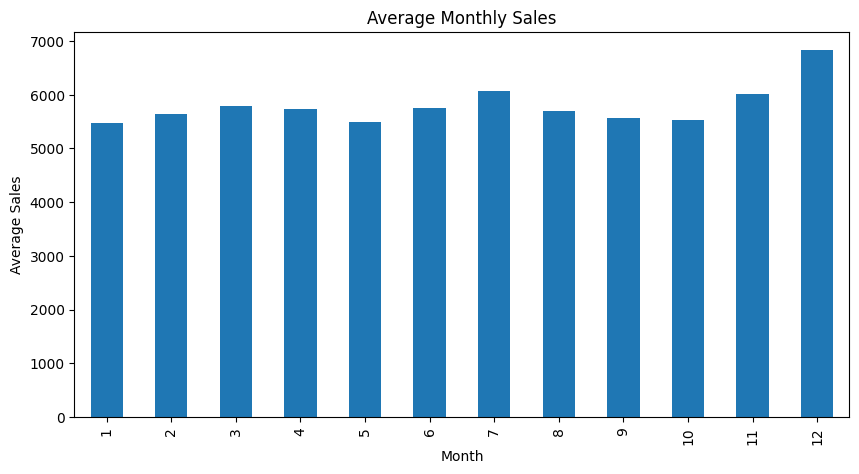

In [24]:
monthly_sales = df.groupby('Month')['Sales'].mean()

monthly_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Monthly Sales")

plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

## Holiday vs Normal Day Sales

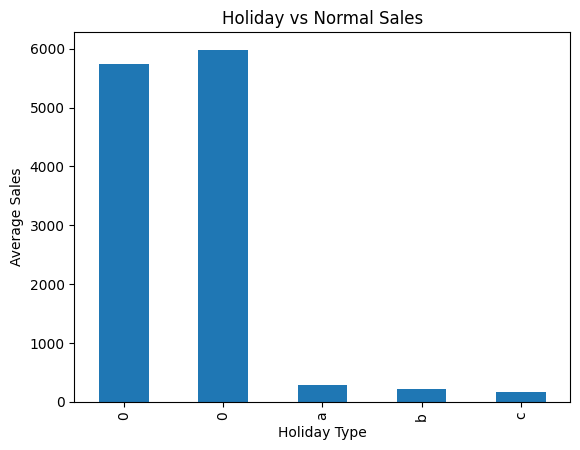

In [25]:
holiday_sales = df.groupby('StateHoliday')['Sales'].mean()

holiday_sales.plot(kind='bar')

plt.title("Holiday vs Normal Sales")

plt.xlabel("Holiday Type")
plt.ylabel("Average Sales")

plt.show()

## Correlation Heatmap

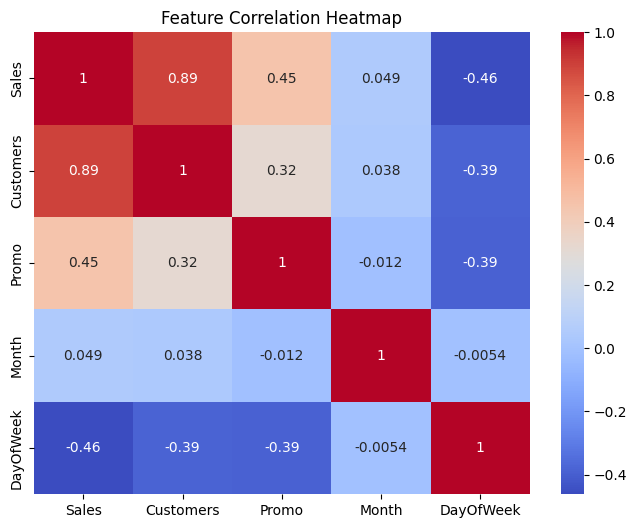

In [26]:
numeric_cols = df[
    [
        'Sales',
        'Customers',
        'Promo',
        'Month',
        'DayOfWeek'
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

# Sales Forecasting Model using Prophet

In [27]:
from prophet import Prophet

## Preparing Data for Prophet Model

In [28]:
prophet_df = weekly_sales.rename(
    columns={
        'Date':'ds',
        'Sales':'y'
    }
)

In [29]:
prophet_df.head()

,ds,y
0,2013-01-06,26129335
1,2013-01-13,49275222
2,2013-01-20,34377765
3,2013-01-27,46040169
4,2013-02-03,38466029


## Train-Test Split

In [30]:
split = int(len(prophet_df)*0.8)

train = prophet_df[:split]

test = prophet_df[split:]

## Training Prophet Model

In [31]:
model = Prophet()

In [32]:
model.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


## Forecasting Future Sales

In [33]:
future = model.make_future_dataframe(
    periods=len(test),
    freq='W'
)

In [34]:
forecast = model.predict(future)

In [35]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-06,4.354552e+07,3.014496e+07,4.839326e+07,4.354552e+07,4.354552e+07,-4.109239e+06,-4.109239e+06,-4.109239e+06,-4.109239e+06,-4.109239e+06,-4.109239e+06,0.0,0.0,0.0,3.943628e+07
1,2013-01-13,4.354549e+07,3.058160e+07,5.063090e+07,4.354549e+07,4.354549e+07,-2.846781e+06,-2.846781e+06,-2.846781e+06,-2.846781e+06,-2.846781e+06,-2.846781e+06,0.0,0.0,0.0,4.069871e+07
2,2013-01-20,4.354546e+07,3.404662e+07,5.288582e+07,4.354546e+07,4.354546e+07,-3.453849e+04,-3.453849e+04,-3.453849e+04,-3.453849e+04,-3.453849e+04,-3.453849e+04,0.0,0.0,0.0,4.351092e+07
3,2013-01-27,4.354544e+07,3.561952e+07,5.417481e+07,4.354544e+07,4.354544e+07,1.176192e+06,1.176192e+06,1.176192e+06,1.176192e+06,1.176192e+06,1.176192e+06,0.0,0.0,0.0,4.472163e+07
4,2013-02-03,4.354541e+07,3.438797e+07,5.341192e+07,4.354541e+07,4.354541e+07,3.445191e+05,3.445191e+05,3.445191e+05,3.445191e+05,3.445191e+05,3.445191e+05,0.0,0.0,0.0,4.388993e+07


## Forecast Visualization

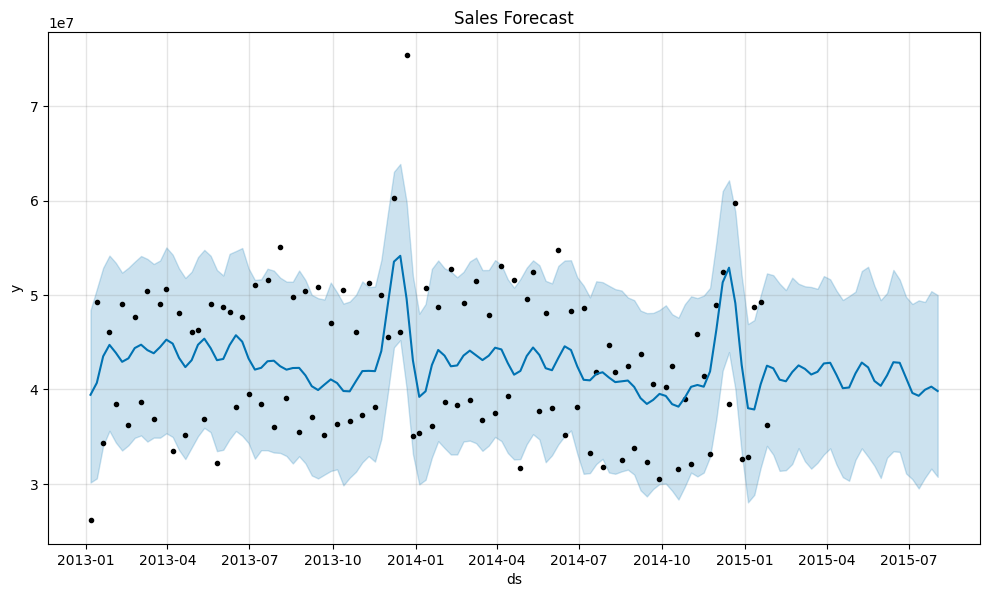

In [36]:
model.plot(forecast)

plt.title("Sales Forecast")

plt.show()

## Model Evaluation Metrics

In [37]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [38]:
y_true = test['y'].values

y_pred = forecast['yhat'].tail(len(test)).values

In [39]:
mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

mape = np.mean(
    np.abs((y_true-y_pred)/y_true)
)*100

print("MAE:", mae)

print("RMSE:", rmse)

print("MAPE:", mape)

MAE: 6911407.66515755
RMSE: 8087711.124536252
MAPE: 14.163982565647174


## Exporting Forecast Data

In [40]:
forecast.to_csv(
    "forecast.csv",
    index=False
)

In [41]:
from google.colab import files

files.download("weekly_sales.csv")

files.download("forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>